# Physics Lab 3.07

In [1]:
from dataclasses import dataclass
from typing import Optional
import math

## Параметры установки (ну и всякое около того)

In [2]:
@dataclass
class Params:
    N1: int
    N2: int
    l: float
    R1: float
    R2: float
    C1: float
    S: float
    mu0: float

In [3]:
params = Params(
    1665,
    970,
    0.078,
    68,
    47*10**4,
    47*10**-8,
    64*10**-6,
    4*math.pi*10**(-7)
)

In [4]:
alpha = params.N1/(params.l * params.R1)
beta = (params.R2 * params.C1)/(params.N2 * params.S)

Delta_alpha = math.sqrt(
    ((params.N1 * 0.001)/(params.l**2 * params.R1))**2 +
    ((params.N1 * 6.8)/(params.l * params.R1**2))**2
)
Delta_beta = math.sqrt(
    ((params.C1 * 47 * 10**3)/(params.N2 * params.S))**2 +
    ((params.R2 * 47 * 10**-9)/(params.N2 * params.S))**2 +
    ((params.R2 * params.C1 * 5 * 10**-6)/(params.N2 * params.S**2))**2
)

## Рассчёт таблицы измерений

In [5]:
@dataclass
class ResultsTableCell:
    U: Optional[int] = None
    X: Optional[float] = None
    H: Optional[float] = None
    DeltaH: Optional[float] = None
    Y: Optional[float] = None
    Ky: Optional[float] = None
    B: Optional[float] = None
    DeltaB: Optional[float] = None
    Kx: Optional[float] = None
    mu: Optional[float] = None
    DeltaMu: Optional[float] = None

    def __repr__(self) -> str:
        return f"[${self.U:.0f}$], [${self.X:.1f}$], " +\
            f"[${self.H:.2f} plus.minus {self.DeltaH:.2f}$], " +\
            f"[${self.Y:.1f}$], [${self.Ky:.2f}$], " +\
            f"[${self.B:.2f} plus.minus {self.DeltaB:.2f}$], " +\
            f"[${self.Kx:.2f}$], " +\
            f"[${self.mu:.2f} plus.minus {self.DeltaMu:.2f}$]"

In [6]:
results = [
    ResultsTableCell(U=20, X=4.0, Y=6.3, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=19, X=4.0, Y=6.0, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=18, X=3.9, Y=5.5, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=17, X=3.5, Y=5.0, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=16, X=3.5, Y=4.5, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=15, X=3.2, Y=4.5, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=14, X=3.1, Y=4.2, Ky=0.05, Kx=0.1),
    ResultsTableCell(U=13, X=6.0, Y=4.0, Ky=0.05, Kx=0.05),
    ResultsTableCell(U=12, X=5.5, Y=4.0, Ky=0.05, Kx=0.05),
    ResultsTableCell(U=11, X=5.2, Y=3.5, Ky=0.05, Kx=0.05),
    ResultsTableCell(U=10, X=5.0, Y=3.2, Ky=0.05, Kx=0.05),
    ResultsTableCell(U=9,  X=5.0, Y=7.5, Ky=0.02, Kx=0.05),
    ResultsTableCell(U=8,  X=4.5, Y=6.8, Ky=0.02, Kx=0.05),
    ResultsTableCell(U=7,  X=4.3, Y=5.3, Ky=0.02, Kx=0.05),
    ResultsTableCell(U=6,  X=3.5, Y=5.0, Ky=0.02, Kx=0.05),
    ResultsTableCell(U=5,  X=4.0, Y=8.5, Ky=0.01, Kx=0.05),
]

In [7]:
H = lambda alpha, Kx, X: alpha*Kx*X
B = lambda beta, Ky, Y: beta*Ky*Y
mu = lambda B, mu0, H: B/(mu0*H)
deltaH = lambda alpha, Kx, X, deltaAlpha, deltaKx, deltaX:\
    math.sqrt(H(deltaAlpha, Kx, X)**2 + H(alpha, deltaKx, X)**2 + H(alpha, Kx, deltaX)**2)
deltaB = lambda beta, Ky, Y, deltaBeta, deltaKy, deltaY:\
    math.sqrt(H(deltaBeta, Ky, Y)**2 + H(beta, deltaKy, Y)**2 + H(beta, Ky, deltaY)**2)
deltaMu = lambda B, mu0, H, deltaB, deltaH:\
    math.sqrt((deltaB/(mu0*H))**2 + ((B*deltaH)/(mu0*H**2))**2)

In [8]:
for elem in results:
    elem.H = H(alpha, elem.Kx, elem.X)
    elem.B = B(beta, elem.Ky, elem.Y)
    elem.mu = mu(elem.B, params.mu0, elem.H)
    elem.DeltaH = deltaH(alpha, elem.Kx, elem.X, Delta_alpha, elem.Kx*0.03, 0.1)
    elem.DeltaB = deltaB(beta, elem.Ky, elem.Y, Delta_beta, elem.Ky*0.03, 0.1)
    elem.DeltaMu = deltaMu(elem.B, params.mu0, elem.H, elem.DeltaB, elem.DeltaH)

In [9]:
print("\t" + ",\n\t".join(map(str, results)))

	[$20$], [$4.0$], [$125.57 plus.minus 13.58$], [$6.3$], [$0.05$], [$1.12 plus.minus 0.19$], [$0.10$], [$7103.53 plus.minus 1401.84$],
	[$19$], [$4.0$], [$125.57 plus.minus 13.58$], [$6.0$], [$0.05$], [$1.07 plus.minus 0.18$], [$0.10$], [$6765.26 plus.minus 1335.53$],
	[$18$], [$3.9$], [$122.43 plus.minus 13.25$], [$5.5$], [$0.05$], [$0.98 plus.minus 0.16$], [$0.10$], [$6360.50 plus.minus 1257.00$],
	[$17$], [$3.5$], [$109.87 plus.minus 11.98$], [$5.0$], [$0.05$], [$0.89 plus.minus 0.15$], [$0.10$], [$6443.11 plus.minus 1277.04$],
	[$16$], [$3.5$], [$109.87 plus.minus 11.98$], [$4.5$], [$0.05$], [$0.80 plus.minus 0.13$], [$0.10$], [$5798.80 plus.minus 1150.71$],
	[$15$], [$3.2$], [$100.45 plus.minus 11.02$], [$4.5$], [$0.05$], [$0.80 plus.minus 0.13$], [$0.10$], [$6342.43 plus.minus 1261.14$],
	[$14$], [$3.1$], [$97.31 plus.minus 10.71$], [$4.2$], [$0.05$], [$0.75 plus.minus 0.12$], [$0.10$], [$6110.56 plus.minus 1217.14$],
	[$13$], [$6.0$], [$94.17 plus.minus 10.03$], [$4.0$], [$0.05$]

## Погрешность

In [10]:
print("Delta mu_m", end=": ")
print(deltaMu(2.68, params.mu0, 549.34, 0.4418, 57.8698))

Delta mu_m: 759.5055571408836


In [11]:
print("Delta alpha", end=": ")
print(Delta_alpha)

Delta alpha: 31.648334506590995


In [12]:
print("Delta beta", end=": ")
print(Delta_beta)

Delta beta: 0.5749015885541969


In [13]:
print("Delta H_c", end=": ")
print(deltaH(alpha, 0.1, 3.8, Delta_alpha, 0.1*0.03, 0.1))

Delta H_c: 12.934226997603226


In [14]:
print("Delta B_r", end=": ")
print(deltaB(beta, 0.1, 6.5, Delta_beta, 0.05*0.03, 0.1))

Delta B_r: 0.3769761942294064


In [15]:
print("Delta H_m", end=": ")
print(deltaH(alpha, 0.1, 17.5, Delta_alpha, 0.1*0.03, 0.1))

Delta H_m: 57.869792922544725


In [16]:
print("Delta B_m", end=": ")
print(deltaB(beta, 0.05, 15.1, Delta_beta, 0.05*0.03, 0.1))

Delta B_m: 0.44182827692919413


In [17]:
chi = lambda Kx, Ky, N1, R2, C1, N2, R1, f: Kx*Ky*(N1*R2*C1)/(N2*R1)*f

In [18]:
Delta_chi = math.sqrt(
    chi(0.1*0.03, 0.05, 1665, 47*10**4, 47*10**-8, 970, 68, 31)**2 +
    chi(0.1, 0.05*0.03, 1665, 47*10**4, 47*10**-8, 970, 68, 31)**2 +
    chi(0.1, 0.05, 0, 47*10**4, 47*10**-8, 970, 68, 31)**2 +
    chi(0.1, 0.05, 1665, 47*10**3, 47*10**-8, 970, 68, 31)**2 +
    chi(0.1, 0.05, 1665, 47*10**4, 47*10**-9, 970, 68, 31)**2 +
    (chi(0.1, 0.05, 1665, 47*10**4, 47*10**-8, 970**2, 68, 31)*0)**2 +
    (chi(0.1, 0.05, 1665, 47*10**4, 47*10**-8, 970, 68**2, 31)*6.8)**2 +
    chi(0.1, 0.05, 1665, 47*10**4, 47*10**-8, 970, 68, 1)**2 
)

print(Delta_chi)

0.0001566269288167903


In [19]:
Delta_P = math.sqrt((357.5*10**-5 * 0.00015)**2 + (8.64 * 10**(-4) * 10**(-4))**2)

In [20]:
print(Delta_P)

5.431657412797682e-07


## Графики

In [54]:
from mnk import CreateEquations
import matplotlib.pyplot as plt

In [55]:
x = [elem.H for elem in results]
y = [elem.B for elem in results]
equations = CreateEquations(x, y)()

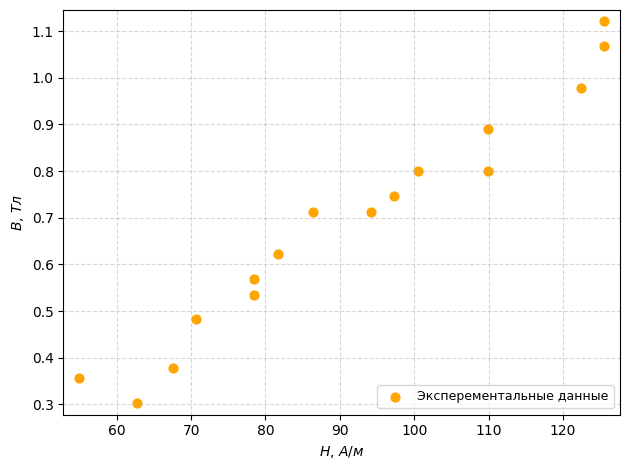

In [56]:
delta_x = abs(min(x)-max(x))
delta_y = abs(min(y)-max(y))
multiplier = 0.06

points = [min(x) - delta_x*multiplier, max(x) + delta_x*multiplier]


ax = plt.axes()
#ax.yaxis.set_minor_locator(MultipleLocator(0.01))
#ax.xaxis.set_minor_locator(MultipleLocator(5))
#ax.xaxis.set_major_locator(MultipleLocator(10))

ax.set_xlim(min(x) - delta_x*multiplier/2, max(x) + delta_x*multiplier/2)
ax.set_ylim(min(y) - delta_y*multiplier/2, max(y) + delta_y*multiplier/2)

# points
plt.scatter(
    x,
    y,
    color='orange',
    s=40,
    marker='o',

    label='Эксперементальные данные'
)

# plot settings
plt.grid(True, alpha=0.5, linestyle='--', which='both')

plt.xlabel(r'$H$, $A/м$', fontsize = 10)
plt.ylabel(r'$B$, $Тл$', fontsize = 10)

plt.legend(
    loc="lower right",
    fontsize=9
)
plt.tight_layout()

plt.savefig("img/H_and_B.png", dpi=700)

plt.show()

In [57]:
max(results, key=lambda x: x.H).DeltaH

13.575823523389

In [58]:
x = [elem.H for elem in results]
y = [elem.mu for elem in results]
equations = CreateEquations(x, y)()

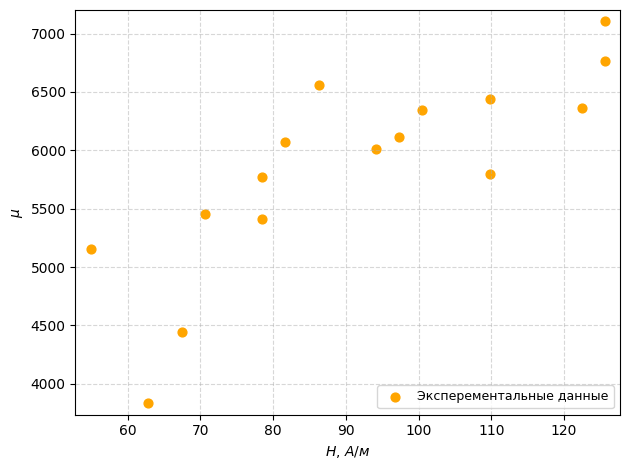

In [59]:
delta_x = abs(min(x)-max(x))
delta_y = abs(min(y)-max(y))
multiplier = 0.06

points = [min(x) - delta_x*multiplier, max(x) + delta_x*multiplier]


ax = plt.axes()
#ax.yaxis.set_minor_locator(MultipleLocator(0.01))
#ax.xaxis.set_minor_locator(MultipleLocator(5))
#ax.xaxis.set_major_locator(MultipleLocator(10))

ax.set_xlim(min(x) - delta_x*multiplier/2, max(x) + delta_x*multiplier/2)
ax.set_ylim(min(y) - delta_y*multiplier/2, max(y) + delta_y*multiplier/2)

# points
plt.scatter(
    x,
    y,
    color='orange',
    s=40,
    marker='o',

    label='Эксперементальные данные'
)

# plot settings
plt.grid(True, alpha=0.5, linestyle='--', which='both')

plt.xlabel(r'$H$, $A/м$', fontsize = 10)
plt.ylabel(r'$\mu$', fontsize = 10)

plt.legend(
    loc="lower right",
    fontsize=9
)
plt.tight_layout()

plt.savefig("img/H_and_mu.png", dpi=700)

plt.show()